In [ ]:
import torch
import torch.nn as nn
import torch_geometric as pyg
from torch_geometric.datasets import Planetoid
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [68]:
torch.cuda.is_available()

True

In [ ]:
# -- Based on Roth and Liebing Code.
# --- Helper functions
def get_data(name):
    path = '../data/' + name
    dataset = Planetoid(root=path, name=name, split='public')
    return dataset[0]

def dirichlet_energy(x, edge_index, edge_weights):
    # Compute the edge differences weighted and squared, then sum and divide by 2
    # This is the version if we where using the L=D-A, not normalized laplacian (L=D^{-1/2}AD^{-1/2})
    edge_diff = edge_weights * (torch.norm(x[edge_index[0]] - x[edge_index[1]], dim=1) ** 2)
    return edge_diff.sum() / 2

# --- Model Definition

class SimpleModel(nn.Module):
    def __init__(self, in_dim, h_dim, num_layers, conv, scale_weights=2.0):
        super().__init__()
        self.enc = nn.Linear(in_dim, h_dim)
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            if conv == 'GCN':
                layer = pyg.nn.GCNConv(h_dim, h_dim, bias=False, add_self_loops=True)
                if scale_weights != 1:
                    layer.lin.weight.data = layer.lin.weight.data * scale_weights
            elif conv == 'GAT':
                layer = pyg.nn.GATConv(h_dim, h_dim, bias=False, add_self_loops=True)
                if scale_weights != 1:
                    layer.lin_src.weight.data = layer.lin_src.weight.data * scale_weights
            elif conv == 'SAGE':
                layer = pyg.nn.SAGEConv(h_dim, h_dim, bias=False)
                if scale_weights != 1:
                    layer.lin_l.weight.data = layer.lin_l.weight.data * scale_weights
                    layer.lin_r.weight.data = layer.lin_r.weight.data * scale_weights
            elif conv == 'GIN':
                # Create an MLP for GIN. Adjust hidden dimensions if needed.
                mlp = nn.Sequential(
                    nn.Linear(h_dim, h_dim),
                    nn.ReLU(),
                    nn.Linear(h_dim, h_dim)
                )
                layer = pyg.nn.GINConv(mlp)
                # Scale the weights of each linear layer in the MLP.
                if scale_weights != 1:
                    for m in mlp:
                        if isinstance(m, nn.Linear):
                            m.weight.data = m.weight.data * scale_weights
            else:
                raise ValueError(f"Unsupported conv type: {conv}")
            self.convs.append(layer)
        self.num_layers = num_layers

    def forward(self, data):
        # Precompute the random-walk normalized adjacency:
        A = pyg.utils.to_dense_adj(data.edge_index)[0]
        D_inv = torch.diag(1 / torch.sum(A, dim=1)).to(A.device)
        A_rw = D_inv @ A
        edge_index, edge_weights = pyg.utils.dense_to_sparse(A_rw)
        
        energies, norms = [], []
        x = self.enc(data.x)
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = torch.relu(x)
            energies.append(dirichlet_energy(x, edge_index, edge_weights))
            norms.append(torch.norm(x) ** 2)
        return energies, norms

# --- Run function to execute the experiment

def run(conv, dataset, num_layers, weight_scale):
    data = get_data(dataset)
    # Consider only the largest connected component and remove self-loops
    data = pyg.transforms.LargestConnectedComponents()(data)
    data.edge_index = pyg.utils.remove_self_loops(data.edge_index)[0]
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleModel(data.num_node_features, 16, num_layers, conv, weight_scale).to(device)
    data = data.to(device)
    
    with torch.no_grad():
        model.eval()
        energies, norms = model(data)
    
    return {
        'Dirichlet energy': torch.FloatTensor(energies).detach().cpu(),
        'Norm': torch.FloatTensor(norms).detach().cpu(),
        'conv': conv
    }

In [70]:
def plot_energies(stat_list, postfix, show_std=True):
    """
    Plots Dirichlet Energy and Norm on a log–log plot,
    dynamically adapting to the number of layers. The legend displays:
      - One colored solid line per method (indicating the method).
      - Two black dummy lines (solid for Dirichlet energy and dashed for Norm).
    If show_std is True, the ±1 standard deviation is shown as shaded regions.
    """
    plt.figure(figsize=(6, 3))
    num_layers = len(stat_list[0]['Dirichlet energy'])
    x = np.arange(1, num_layers + 1)
    
    # Define colors for the methods; update length to include GIN, etc.
    colors = ['#404788', '#238A8D', '#55C667', '#D55E00']
    
    # Plot each method's curves.
    for i in range(len(stat_list)):
        # Dirichlet Energy (solid line)
        energy = stat_list[i]['Dirichlet energy'].numpy()
        energy_std = stat_list[i]['Dirichlet energy std'].numpy()
        plt.plot(x, energy, '-', c=colors[i])
        if show_std:
            plt.fill_between(x, energy - energy_std, energy + energy_std,
                             alpha=0.2, color=colors[i])
        # Norm (dashed line)
        norm = stat_list[i]['Norm'].numpy()
        norm_std = stat_list[i]['Norm std'].numpy()
        plt.plot(x, norm, '--', c=colors[i])
        if show_std:
            plt.fill_between(x, norm - norm_std, norm + norm_std,
                             alpha=0.2, color=colors[i])
    
    # Use log scale for both axes.
    plt.yscale('log')
    plt.xscale('log')
    
    # Create a custom legend.
    # First, one handle per method using its color.
    method_handles = []
    method_labels = []
    # Get the unique methods (e.g. SAGE, GAT, GCN, GIN); assuming the order in stat_list.
    for i, stat in enumerate(stat_list):
        method_handles.append(Line2D([0], [0], color=colors[i], lw=2))
        method_labels.append(stat['conv'])
    
    # Next, create two dummy handles for the line styles (black lines).
    style_handles = [Line2D([0], [0], color='black', lw=2, linestyle='-'),
                     Line2D([0], [0], color='black', lw=2, linestyle='--')]
    style_labels = ['Dirichlet Energy', 'Norm']
    
    # Combine the handles and labels.
    all_handles = method_handles + style_handles
    all_labels = method_labels + style_labels
    
    plt.legend(all_handles, all_labels, ncol=2)
    
    # Create dynamic x–ticks.
    if num_layers > 1:
        ticks = np.geomspace(1, num_layers, num=8, dtype=int)
        ticks = np.unique(ticks)
    else:
        ticks = [1]
    plt.xticks(ticks, ticks)
    
    plt.xlabel('Number of layers')
    plt.ylabel('Magnitude')
    plt.title('Dirichlet Energy and Norm')
    plt.savefig(f'DE-Norm-Depth-{postfix}.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()


def plot_ratio(stat_list, postfix, show_std=True):
    """
    Plots the ratio (Rayleigh Quotient) on a log–log plot,
    automatically adapting to the number of layers.
    The legend shows one entry per method (color–coded).
    """
    plt.figure(figsize=(6, 3))
    num_layers = len(stat_list[0]['Ratio'])
    x = np.arange(1, num_layers + 1)
    colors = ['#404788', '#238A8D', '#55C667', '#D55E00']
    
    for i in range(len(stat_list)):
        ratio = stat_list[i]['Ratio'].numpy()
        ratio_std = stat_list[i]['Ratio std'].numpy()
        plt.plot(x, ratio, '-', label=f"{stat_list[i]['conv']}", c=colors[i])
        if show_std:
            plt.fill_between(x, ratio - ratio_std, ratio + ratio_std,
                             alpha=0.2, color=colors[i])
    
    plt.yscale('log')
    plt.xscale('log')
    
    # For ratio, we only need one legend per method.
    plt.legend(ncol=2)
    
    if num_layers > 1:
        ticks = np.geomspace(1, num_layers, num=8, dtype=int)
        ticks = np.unique(ticks)
    else:
        ticks = [1]
    plt.xticks(ticks, ticks)
    
    plt.xlabel('Number of layers')
    plt.ylabel('Rayleigh Quotient')
    plt.title('Rayleigh Quotient' + (' with Standard Deviation' if show_std else ''))
    plt.savefig(f'RQ-Depth-{postfix}.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

In [71]:
dataset = 'Cora'
num_layers = 64  # Number of layers to evaluate.
seeds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  # List of seeds for multiple runs

# Run experiments for both weight scales and store averaged results and standard deviations in a dictionary.
stats_dict = {}
for weight_scale in [1.0, 2.0]:
    stat_list = []  # This will contain one dictionary per convolution type.
    for conv in ['SAGE', 'GAT', 'GCN', 'GIN']:
        energies_all = []
        norms_all = []
        ratios_all = []
        for seed in seeds:
            torch.manual_seed(seed)  # Set the seed for reproducibility.
            stats = run(conv, dataset, num_layers, weight_scale)
            # Ensure shape is (1, num_layers).
            energy = stats['Dirichlet energy'].unsqueeze(0)
            norm = stats['Norm'].unsqueeze(0)
            ratio = energy / norm
            energies_all.append(energy)
            norms_all.append(norm)
            ratios_all.append(ratio)
        # Concatenate along the seed dimension.
        energies_tensor = torch.cat(energies_all, dim=0)
        norms_tensor = torch.cat(norms_all, dim=0)
        ratios_tensor = torch.cat(ratios_all, dim=0)

        # Compute nanmean and std along the seed dimension.
        energy_avg = energies_tensor.nanmean(dim=0)
        energy_std = energies_tensor.std(dim=0)
        norm_avg = norms_tensor.nanmean(dim=0)
        norm_std = norms_tensor.std(dim=0)
        ratio_avg = ratios_tensor.nanmean(dim=0)
        ratio_std = ratios_tensor.std(dim=0)

        # Store the results.
        stat_list.append({
            'conv': conv,
            'Dirichlet energy': energy_avg,
            'Dirichlet energy std': energy_std,
            'Norm': norm_avg,
            'Norm std': norm_std,
            'Ratio': ratio_avg,
            'Ratio std': ratio_std
        })
    stats_dict[weight_scale] = stat_list



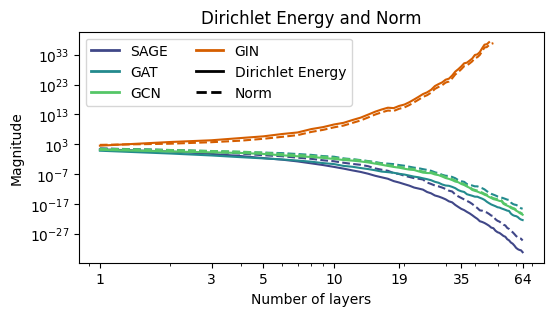

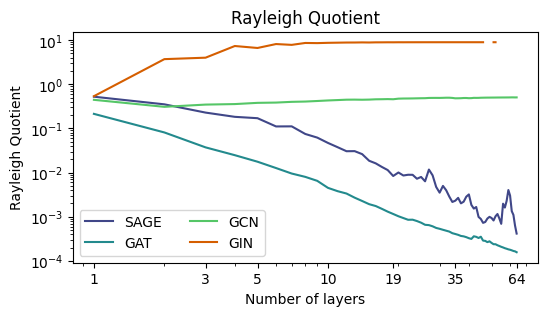

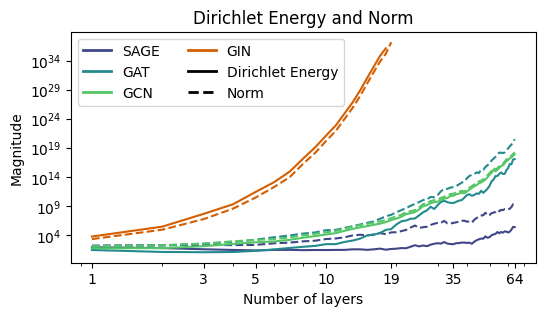

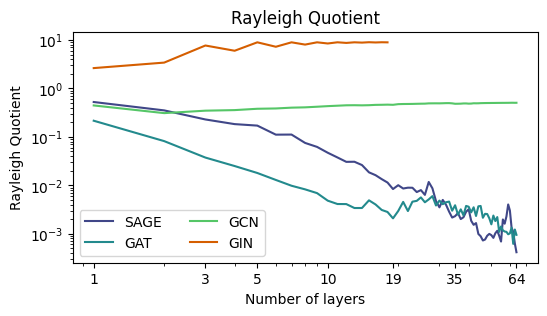

In [72]:
# Plotting without standard deviation:
for weight_scale, stat_list in stats_dict.items():
    plot_energies(stat_list, weight_scale, show_std=False)
    plot_ratio(stat_list, weight_scale, show_std=False)


# Deviations in log-space - Beauty plot

Instead of computing the error bands in linear space we instead compute the mean and standard deviation in logarithmic space and then “back‑transform” them. In other words, for each x‐value we compute

$$
\mu_{\log} = \frac{1}{N}\sum_{i=1}^{N}\ln\bigl(v_i+\varepsilon\bigr)
\quad\text{and}\quad
\sigma_{\log} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\Bigl[\ln\bigl(v_i+\varepsilon\bigr)-\mu_{\log}\Bigr]^2}\,,
$$

and then set the plotted mean as

$$
v_{\mathrm{mean}} = \exp(\mu_{\log})
$$

with error bands given by

$$
v_{\mathrm{lower}} = \exp(\mu_{\log}-\sigma_{\log}), \qquad 
v_{\mathrm{upper}} = \exp(\mu_{\log}+\sigma_{\log}).
$$

i.e.

$$
\text{lower} = \exp\Bigl(\ln(\text{mean}) - \sigma_{\log}\Bigr), \quad 
\text{upper} = \exp\Bigl(\ln(\text{mean}) + \sigma_{\log}\Bigr),
$$
   where $\sigma_{\log}$ is the log-space standard deviation. When plotted on a log‑scaled axis, these bounds appear symmetric.

In [ ]:

def plot_energies(stat_list, postfix, show_std=True):
    """
    Plots Dirichlet Energy and Norm on a log–log plot, dynamically adapting
    to the number of layers. The legend displays:
      - One colored solid line per method (indicating the method).
      - Two black dummy lines (solid for Dirichlet Energy and dashed for Norm).
    If show_std is True, the ±1 geometric error (computed in log space) is shown.
    """
    plt.figure(figsize=(4, 4))
    num_layers = len(stat_list[0]['Dirichlet energy'])
    x = np.arange(1, num_layers + 1)
    
    # Define colors for the methods.
    colors = ['#404788', '#238A8D', '#55C667', '#D55E00']
    
    for i in range(len(stat_list)):
        # Retrieve geometric mean and log-space std for Dirichlet Energy.
        energy = stat_list[i]['Dirichlet energy'].numpy()
        energy_log_std = stat_list[i]['Dirichlet energy std'].numpy()  # σ_log
        # Compute multiplicative error bounds:
        lower_energy = np.exp(np.log(energy) - energy_log_std)
        upper_energy = np.exp(np.log(energy) + energy_log_std)
        plt.plot(x, energy, '-', c=colors[i])
        if show_std:
            plt.fill_between(x, lower_energy, upper_energy, alpha=0.2, color=colors[i])
        
        # For Norm:
        norm = stat_list[i]['Norm'].numpy()
        norm_log_std = stat_list[i]['Norm std'].numpy()
        lower_norm = np.exp(np.log(norm) - norm_log_std)
        upper_norm = np.exp(np.log(norm) + norm_log_std)
        plt.plot(x, norm, '--', c=colors[i])
        if show_std:
            plt.fill_between(x, lower_norm, upper_norm, alpha=0.2, color=colors[i])
    
    plt.yscale('log')
    plt.xscale('log')
    
    # Create custom legend:
    # One colored handle per method:
    method_handles = [Line2D([0], [0], color=colors[i], lw=2) for i in range(len(stat_list))]
    method_labels = [stat_list[i]['conv'] for i in range(len(stat_list))]
    # Two dummy black lines for line styles.
    style_handles = [Line2D([0], [0], color='black', lw=2, linestyle='-'),
                     Line2D([0], [0], color='black', lw=2, linestyle='--')]
    style_labels = ['Dirichlet Energy', 'Norm']
    
    all_handles = method_handles + style_handles
    all_labels = method_labels + style_labels
    plt.legend(all_handles, all_labels, ncol=2)
    
    # Dynamic x-ticks:
    ticks = np.geomspace(1, num_layers, num=8, dtype=int)
    ticks = np.unique(ticks)
    plt.xticks(ticks, ticks)
    
    plt.xlabel('Number of layers')
    plt.ylabel('Magnitude')
    plt.title('Dirichlet Energy and Norm')
    plt.savefig(f'DE-Norm-Depth-{postfix}-STD.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

def plot_ratio(stat_list, postfix, show_std=True):
    """
    Plots the Rayleigh Quotient on a log–log plot, automatically adapting
    to the number of layers. The legend shows one entry per method (color-coded).
    The error is computed in log space and back-transformed.
    """
    plt.figure(figsize=(4, 4))
    num_layers = len(stat_list[0]['Ratio'])
    x = np.arange(1, num_layers + 1)
    colors = ['#404788', '#238A8D', '#55C667', '#D55E00']
    
    for i in range(len(stat_list)):
        ratio = stat_list[i]['Ratio'].numpy()
        ratio_log_std = stat_list[i]['Ratio std'].numpy()
        lower_ratio = np.exp(np.log(ratio) - ratio_log_std)
        upper_ratio = np.exp(np.log(ratio) + ratio_log_std)
        plt.plot(x, ratio, '-', label=f"{stat_list[i]['conv']}", c=colors[i])
        if show_std:
            plt.fill_between(x, lower_ratio, upper_ratio, alpha=0.2, color=colors[i])
    
    plt.yscale('log')
    plt.xscale('log')
    plt.legend(ncol=2)
    
    ticks = np.geomspace(1, num_layers, num=8, dtype=int)
    ticks = np.unique(ticks)
    plt.xticks(ticks, ticks)
    
    plt.xlabel('Number of layers')
    plt.ylabel('Rayleigh Quotient')
    plt.title('Rayleigh Quotient')
    plt.savefig(f'RQ-Depth-{postfix}-STD.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()


In [ ]:


epsilon = 1e-40 # small value to avoid log(0)

dataset = 'Cora'
num_layers = 64  # Number of layers to evaluate.
seeds = torch.linspace(0, 50, 50).long()  # List of seeds

# Run experiments for both weight scales and store geometric (log-space) means and std.
stats_dict = {}
for weight_scale in [1.0, 2.0]:
    stat_list = []  # One dictionary per convolution type.
    for conv in ['SAGE', 'GAT', 'GCN', 'GIN']:
        energies_all = []
        norms_all = []
        ratios_all = []
        for seed in seeds:
            torch.manual_seed(seed)  # Set seed for reproducibility.
            stats = run(conv, dataset, num_layers, weight_scale)
            # Ensure shape (1, num_layers) by unsqueezing:
            energy = stats['Dirichlet energy'].unsqueeze(0)
            norm = stats['Norm'].unsqueeze(0)
            ratio = energy / norm
            energies_all.append(energy)
            norms_all.append(norm)
            ratios_all.append(ratio)
        # Concatenate along seed dimension:
        energies_tensor = torch.cat(energies_all, dim=0)
        norms_tensor = torch.cat(norms_all, dim=0)
        ratios_tensor = torch.cat(ratios_all, dim=0)
        
        # Compute geometric averages and log-space standard deviations elementwise.
        # For Dirichlet energy:
        energy_log = torch.log(energies_tensor.clamp(min=epsilon))
        energy_log_avg = energy_log.mean(dim=0)
        energy_log_std = energy_log.std(dim=0)
        energy_geom = torch.exp(energy_log_avg)
        
        # For Norm:
        norm_log = torch.log(norms_tensor.clamp(min=epsilon))
        norm_log_avg = norm_log.mean(dim=0)
        norm_log_std = norm_log.std(dim=0)
        norm_geom = torch.exp(norm_log_avg)
        
        # For Ratio:
        ratio_log = torch.log(ratios_tensor.clamp(min=epsilon))
        ratio_log_avg = ratio_log.mean(dim=0)
        ratio_log_std = ratio_log.std(dim=0)
        ratio_geom = torch.exp(ratio_log_avg)
        
        stat_list.append({
            'conv': conv,
            'Dirichlet energy': energy_geom,
            'Dirichlet energy std': energy_log_std,  # log-space std
            'Norm': norm_geom,
            'Norm std': norm_log_std,                # log-space std
            'Ratio': ratio_geom,
            'Ratio std': ratio_log_std               # log-space std
        })
    stats_dict[weight_scale] = stat_list


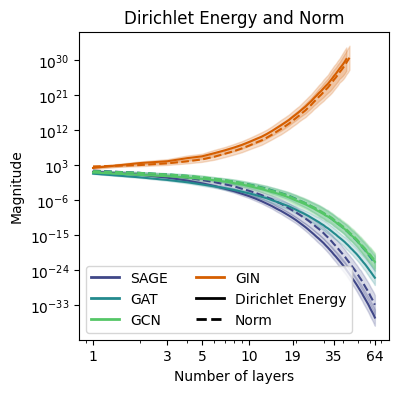

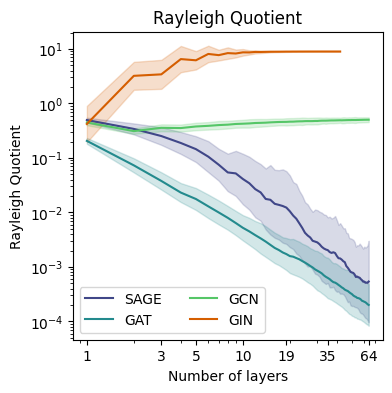

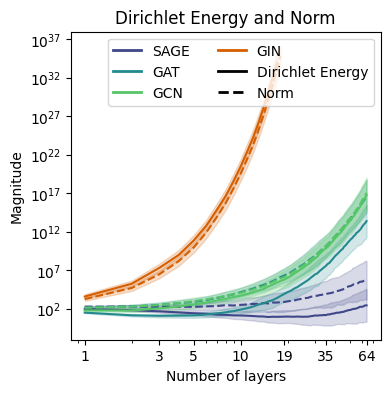

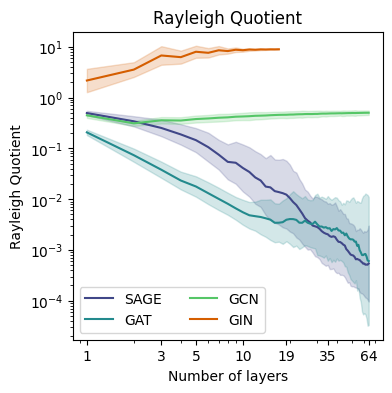

In [91]:
# Plotting without standard deviation:
for weight_scale, stat_list in stats_dict.items():
    plot_energies(stat_list, weight_scale, show_std=True)
    plot_ratio(stat_list, weight_scale, show_std=True)